In [152]:
# test-file-5.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

In [153]:
# specifying the path to the csv file that needs to be imported (the overlap.csv)
input_file_path = "/mnt/d/code/phd/image-analysis/synapse-counting/output_data/overlap.csv"

df = pd.read_csv(input_file_path)
print(df.head(3))

           image file name  overlap_um2  overlap_um2_rot  vglut1_threshold  \
0  OE_Exp1_IHC_Exp1_CA1_SO     6.861486         3.312811        989.434429   
1  OE_Exp1_IHC_Exp1_CA1_SO    14.328713         6.555935        989.434429   
2  OE_Exp1_IHC_Exp1_CA1_SR     7.837104         3.162716       1053.083197   

   psd95_threshold  
0       542.062486  
1       542.062486  
2       596.000658  


In [154]:
# transforming the df into the right format
df_melted = pd.melt(df, id_vars = ["image file name"], value_vars=["overlap_um2", "overlap_um2_rot"],
                    var_name="condition", value_name="overlap (um2)")

df_melted["condition"] = df_melted["condition"].apply(lambda x: "rotated" if "overlap_um2_rot" in x else "actual")

df_melted['hippocampal layer'] = df_melted['image file name'].apply(lambda x: ' '.join(x.split('_')[-2:]))

df_final = df_melted.drop("image file name", axis=1)

print(df_final)

   condition  overlap (um2) hippocampal layer
0     actual       6.861486            CA1 SO
1     actual      14.328713            CA1 SO
2     actual       7.837104            CA1 SR
3     actual      46.792118            CA1 SR
4     actual      75.712209            CA3 SL
5     actual     135.123029            CA3 SL
6     actual      31.187598            CA3 SO
7     actual      35.266966            CA3 SO
8     actual      10.217181            CA3 SR
9     actual      35.256245            CA3 SR
10    actual      16.821362            CA1 SO
11    actual       8.828803            CA1 SO
12    actual      28.469806            CA1 SR
13    actual      16.135213            CA1 SR
14    actual      48.936332            CA3 SL
15    actual      36.440923            CA3 SL
16    actual       8.378518            CA3 SO
17    actual      11.921832            CA3 SO
18    actual      25.521512            CA3 SR
19    actual      11.358976            CA3 SR
20   rotated       3.312811       

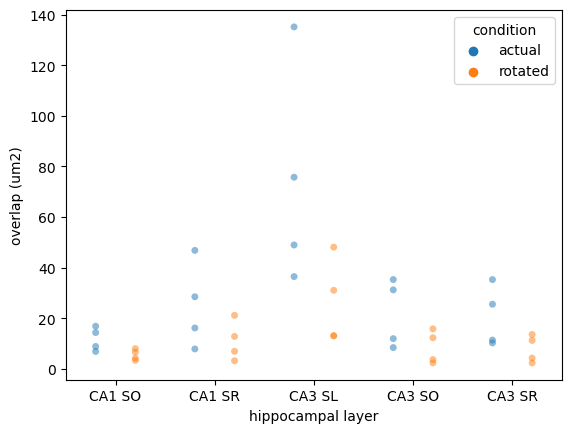

In [155]:
# creating the plot
p = sns.stripplot(y="overlap (um2)", x="hippocampal layer", hue = "condition",
                        data = df_final,
                        jitter = False,
                        dodge=True,
                        marker = "o",
                        alpha = 0.5)


In [156]:
# exporting the plot as png
output_folder = "/mnt/d/code/phd/image-analysis/synapse-counting/output_data/"

output_file = os.path.join(output_folder, "dotplot.png")
plot = p.get_figure()
plot.savefig(output_file, dpi = 300)